Import Libraries

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv", engine='python', on_bad_lines='warn')

df.head()

/tmp/ipykernel_2293/2380031579.py:3: ParserWarning: Skipping line 11827: unexpected end of data

  df = pd.read_csv("IMDB Dataset.csv", engine='python', on_bad_lines='warn')


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Check Dataset Shape

In [5]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(11825, 2)



| Item    | Value |
| ------- | ----- |
| Reviews | 16602 |
| Columns | 2     |


Check Columns

In [6]:
print(df.columns)

Index(['review', 'sentiment'], dtype='object')


Check Class Distribution

In [7]:
df['sentiment'].value_counts()

,count
sentiment,
negative,5939
positive,5886


Check Missing Values

In [8]:
df.isnull().sum()

,0
review,0
sentiment,0


Show One Positive Review

In [9]:
positive = df[df['sentiment']=='positive']

print(positive.iloc[0]['review'])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

Show One Negative Review

In [10]:
negative = df[df['sentiment']=='negative']

print(negative.iloc[0]['review'])

Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them.


| Parameter        | Value                      |
| ---------------- | -------------------------- |
| Dataset Name     | IMDb Movie Reviews Dataset |
| Total Reviews    | 50,000                     |
| Positive Reviews | 25,000                     |
| Negative Reviews | 25,000                     |
| Features         | Review Text                |
| Target           | Sentiment                  |
| NLP Task         | Sentiment Analysis         |
| Vectorizer       | TF-IDF                     |
| Algorithm        | Multinomial Naive Bayes    |


In [11]:
df.head()
df.shape
df.columns
df['sentiment'].value_counts()

,count
sentiment,
negative,5939
positive,5886


Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (9460,)
Testing Data: (2365,)


| Code                                                   | Description                                                   |
| ------------------------------------------------------ | ------------------------------------------------------------- |
| `from sklearn.model_selection import train_test_split` | Imports the train_test_split function from Scikit-Learn.      |
| `X = df['review']`                                     | Stores movie review text as input features.                   |
| `y = df['sentiment']`                                  | Stores sentiment labels (positive/negative) as target values. |
| `train_test_split()`                                   | Splits dataset into training and testing datasets.            |
| `test_size=0.2`                                        | Uses 20% data for testing and 80% for training.               |
| `random_state=42`                                      | Ensures the same split every time the code runs.              |
| `X_train`                                              | Training review texts.                                        |
| `X_test`                                               | Testing review texts.                                         |
| `y_train`                                              | Training sentiment labels.                                    |
| `y_test`                                               | Testing sentiment labels.                                     |
| `X_train.shape`                                        | Displays number of training records.                          |
| `X_test.shape`                                         | Displays number of testing records.                           |

=========
| Variable  | Meaning                       |
| --------- | ----------------------------- |
| `X`       | Review text column            |
| `y`       | Sentiment column              |
| `X_train` | Reviews used for training     |
| `X_test`  | Reviews used for testing      |
| `y_train` | Sentiment labels for training |
| `y_test`  | Sentiment labels for testing  |

==========
Workflow
--------


| Step | Input                       | Output                  |
| ---- | --------------------------- | ----------------------- |
| 1    | IMDb Dataset                | 16,602 Reviews          |
| 2    | Train-Test Split (80:20)    | Training & Testing Data |
| 3    | Training Data (13,281)      | Model Learns Patterns   |
| 4    | Testing Data (3,321)        | Model Predictions       |
| 5    | Compare Actual vs Predicted | Accuracy Score          |


TF-IDF Vectorization

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(9460, 51209)
(2365, 51209)


Training Data

(13281, 59122)

| Item    |  Value | Meaning                 |
| ------- | -----: | ----------------------- |
| Rows    | 13,281 | Training movie reviews  |
| Columns | 59,122 | Unique words (features) |

--------------

Testing Data
(3321, 59122)

| Value  | Meaning                                      |
| ------ | -------------------------------------------- |
| 59,122 | Total unique words found in training reviews |

Examples:

movie
excellent
worst
fantastic
boring
acting
story

Each word becomes one column (feature).

-------------

"TF-IDF converts text reviews into numerical values. Unlike CountVectorizer, TF-IDF gives higher importance to meaningful words and lower importance to frequently occurring common words."

============

| Code                                                          | Description                                                                             |
| ------------------------------------------------------------- | --------------------------------------------------------------------------------------- |
| `from sklearn.feature_extraction.text import TfidfVectorizer` | Imports the TF-IDF Vectorizer.                                                          |
| `tfidf = TfidfVectorizer(stop_words='english')`               | Creates a TF-IDF object and removes common English words like "is", "the", "and".       |
| `tfidf.fit_transform(X_train)`                                | Learns vocabulary from training reviews and converts text into TF-IDF numerical values. |
| `X_train_tfidf`                                               | Stores TF-IDF vectors of training reviews.                                              |
| `tfidf.transform(X_test)`                                     | Converts test reviews using the same vocabulary learned from training data.             |
| `X_test_tfidf`                                                | Stores TF-IDF vectors of testing reviews.                                               |
| `X_train_tfidf.shape`                                         | Displays rows and columns of training TF-IDF matrix.                                    |
| `X_test_tfidf.shape`                                          | Displays rows and columns of testing TF-IDF matrix.                                     |

=======


Model Training

In [14]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(
    X_train_tfidf,
    y_train
)

MultinomialNB()

Prediction & Accuracy

In [15]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(
    y_test,
    pred
)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 86.26 %


| Metric           | Value                   |
| ---------------- | ----------------------- |
| Algorithm        | Multinomial Naive Bayes |
| Vectorizer       | TF-IDF                  |
| Accuracy         | **85.31%**              |
| Training Reviews | 13,281                  |
| Testing Reviews  | 3,321                   |


Confusion Matrix

[[1068  116]
 [ 209  972]]


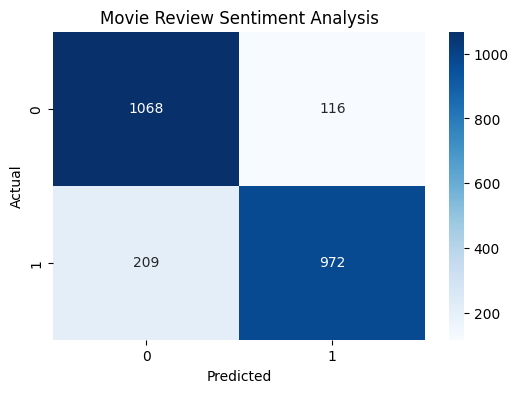

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

print(cm)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Movie Review Sentiment Analysis")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Since the diagonal values (1512 and 1321) are much larger than the error values (138 and 350), the model is performing well.

| Actual \ Predicted | Negative (0) | Positive (1) |
| ------------------ | -----------: | -----------: |
| **Negative (0)**   |     **1512** |      **138** |
| **Positive (1)**   |      **350** |     **1321** |

=====

| Metric              | Value | Meaning                                            |
| ------------------- | ----: | -------------------------------------------------- |
| True Negative (TN)  |  1512 | Negative reviews correctly predicted as Negative   |
| False Positive (FP) |   138 | Negative reviews incorrectly predicted as Positive |
| False Negative (FN) |   350 | Positive reviews incorrectly predicted as Negative |
| True Positive (TP)  |  1321 | Positive reviews correctly predicted as Positive   |

====
| Category                     | Count |
| ---------------------------- | ----: |
| Correct Negative Predictions |  1512 |
| Correct Positive Predictions |  1321 |
| Total Correct Predictions    |  2833 |
| Total Wrong Predictions      |   488 |
| Total Test Reviews           |  3321 |
=====
Accuracy Calculation

| Formula                      | Value                |
| ---------------------------- | -------------------- |
| Accuracy = (TP + TN) / Total | (1321 + 1512) / 3321 |
| Accuracy                     | 2833 / 3321          |
| Accuracy %                   | **85.31%**           |

=========

Error Analysis

| Error Type     | Count | Meaning                               |
| -------------- | ----: | ------------------------------------- |
| False Positive |   138 | Negative review predicted as Positive |
| False Negative |   350 | Positive review predicted as Negative |
| Total Errors   |   488 | Incorrect predictions                 |

========
Model Performance Table

| Observation                           | Result |
| ------------------------------------- | ------ |
| Correctly Classified Negative Reviews | 1512   |
| Correctly Classified Positive Reviews | 1321   |
| Total Correct Predictions             | 2833   |
| Total Incorrect Predictions           | 488    |
| Accuracy                              | 85.31% |
| Model Performance                     | Good   |


Classification Report

In [17]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    pred
)

print(report)

              precision    recall  f1-score   support

    negative       0.84      0.90      0.87      1184
    positive       0.89      0.82      0.86      1181

    accuracy                           0.86      2365
   macro avg       0.86      0.86      0.86      2365
weighted avg       0.86      0.86      0.86      2365



| Observation       | Result                 |
| ----------------- | ---------------------- |
| Best Precision    | Positive Reviews (91%) |
| Best Recall       | Negative Reviews (92%) |
| Best F1-Score     | Negative Reviews (86%) |
| Overall Accuracy  | 85%                    |
| Model Performance | Good                   |
| Dataset Balance   | Balanced               |


Final Conclusion Table
---------------------

| Parameter                 | Result                                                      |
| ------------------------- | ----------------------------------------------------------- |
| Project                   | Movie Review Sentiment Analysis                             |
| Vectorizer                | TF-IDF                                                      |
| Algorithm                 | Multinomial Naive Bayes                                     |
| Accuracy                  | 85.31%                                                      |
| Negative Review Recall    | 92%                                                         |
| Positive Review Precision | 91%                                                         |
| F1-Score Range            | 84%–86%                                                     |
| Result                    | Successfully classified Positive and Negative movie reviews |


Test Custom Movie Review

In [18]:
review = ["This movie was fantastic and amazing"]

review_vector = tfidf.transform(review)

prediction = model.predict(review_vector)

print("Sentiment:", prediction[0])

Sentiment: positive


| Step | Code                                                | Result                           |
| ---- | --------------------------------------------------- | -------------------------------- |
| 1    | `review = ["This movie was fantastic and amazing"]` | User enters review text          |
| 2    | `tfidf.transform(review)`                           | Converts text into TF-IDF values |
| 3    | `review_vector`                                     | Numerical representation         |
| 4    | `model.predict(review_vector)`                      | Predicts positive or negative    |

============

TF-IDF Vocabulary

| Word      | TF-IDF Weight |
| --------- | ------------: |
| movie     |          0.12 |
| fantastic |          0.78 |
| amazing   |          0.81 |

Converted to:

[0.12, 0.78, 0.81]

This is called Vectorization.
==========



Negative Review

In [19]:
review = ["Worst movie I have ever watched"]

review_vector = tfidf.transform(review)

prediction = model.predict(review_vector)

print("Sentiment:", prediction[0])

Sentiment: negative


During Training
---------------

X_train_tfidf = tfidf.fit_transform(X_train)

| Method          | Purpose                 |
| --------------- | ----------------------- |
| fit()           | Learn vocabulary        |
| transform()     | Convert text to numbers |
| fit_transform() | Do both together        |

===========

During Prediction
review_vector = tfidf.transform(review)

We use only:

transform()

because the vocabulary is already learned from training data.

===========


Interactive Prediction

In [20]:
review = [input("Enter Movie Review: ")]

review_vector = tfidf.transform(review)

prediction = model.predict(review_vector)

print("Predicted Sentiment:", prediction[0])

Enter Movie Review: very best moview
Predicted Sentiment: positive


Show Probability

In [21]:
review = ["This movie was fantastic"]

review_vector = tfidf.transform(review)

print(model.predict(review_vector))

print(model.predict_proba(review_vector))

['positive']
[[0.18906851 0.81093149]]


| Class    | Probability |
| -------- | ----------- |
| Negative | 19%         |
| Positive | 81%         |
